In [4]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 19.3 MB/s eta 0:00:00


# Libaries

In [5]:
import pandas as pd
import numpy as np

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.tools import diff
from statsmodels.tsa.arima_model import ARMAResults,ARIMAResults
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tools.eval_measures import rmse
from statsmodels.graphics.tsaplots import month_plot,quarter_plot
from statsmodels.tsa.stattools import adfuller


from pandas.plotting import lag_plot
import matplotlib.pyplot as plt
from dateutil.parser import parse
from scipy import stats
from scipy.stats import normaltest
from sklearn.metrics import mean_squared_error
from pmdarima import auto_arima

In [2]:
!unzip -o dataset.zip

Archive:  dataset.zip
  inflating: international-airline-passengers.csv  


# Load data

In [6]:
df=pd.read_csv("/content/international-airline-passengers.csv",index_col='Month',parse_dates=True)
df.head()

,International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60
Month,
1949-01,112.0
1949-02,118.0
1949-03,132.0
1949-04,129.0
1949-05,121.0


In [7]:
df.shape

(145, 1)

In [12]:
df.rename(columns={"International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60":'Thousands of Passengers'},inplace=True)
df.head()

,Thousands of Passengers
Month,
1949-01,112.0
1949-02,118.0
1949-03,132.0
1949-04,129.0
1949-05,121.0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 145 entries, 1949-01 to International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60
Data columns (total 1 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Thousands of Passengers  144 non-null    float64
dtypes: float64(1)
memory usage: 6.3+ KB


In [15]:
df[df.isnull().any(axis=1)]

,Thousands of Passengers
Month,
International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60,NaN


In [16]:
df.tail()

,Thousands of Passengers
Month,
1960-09,508.0
1960-10,461.0
1960-11,390.0
1960-12,432.0
International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60,NaN


In [17]:
df.dropna(inplace=True)

In [18]:
df.index=pd.to_datetime(df.index)

In [19]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

In [20]:
df=df.asfreq('MS')

In [21]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq='MS')

# Descriptive Analysis

<Axes: xlabel='Month'>

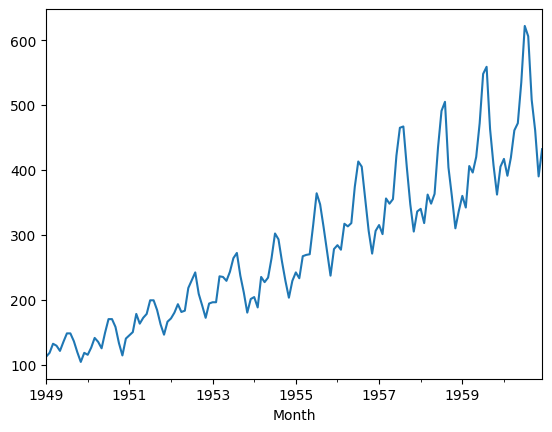

In [22]:
df['Thousands of Passengers'].plot()

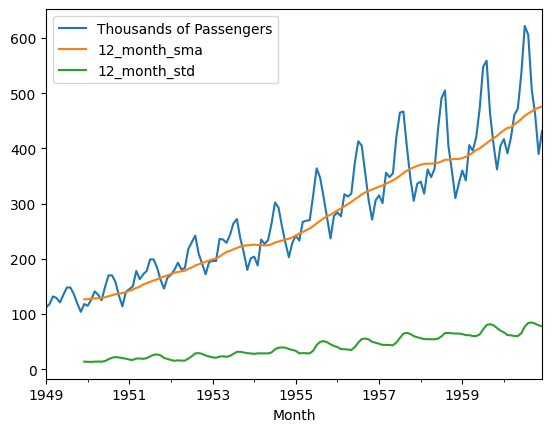

In [25]:
df['12_month_sma']=df['Thousands of Passengers'].rolling(window=12).mean()
df['12_month_std']=df['Thousands of Passengers'].rolling(window=12).std()
df[['Thousands of Passengers','12_month_sma','12_month_std']].plot()
plt.show()

From the above graph, we see that rolling mean itself has a trend component even though rolling standard deviation is fairly constant with time. For our time series to be stationary, we need to ensure that both the rolling statistics ie: mean & std. dev. remain time invariant or constant with time.

# Visulization

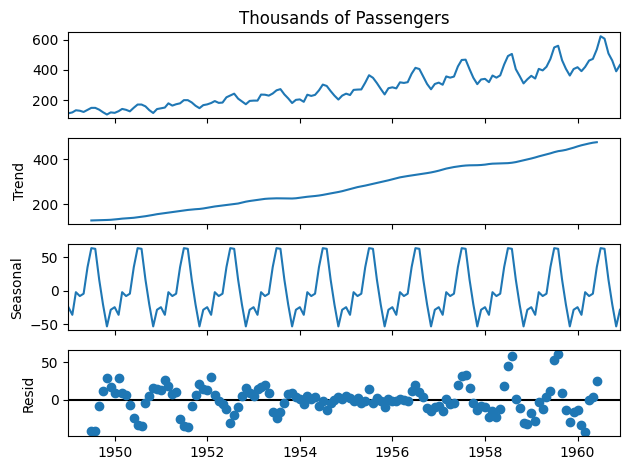

In [28]:
result=seasonal_decompose(df['Thousands of Passengers'],model='add')
result.plot()
plt.show()

* Observation: Notice the Seasonal plot. The peaks and valleys are always between approximately $+60$ and $-50$.
* The Problem: Look at the original "Thousands of Passengers" plot. As time goes on, the seasonal swings (the "wiggles") get larger and larger.
* The Result: Because the additive model assumes the seasonal effect is a constant amount, it fails to capture that growing magnitude. This shows up in the Resid (Residual) plot, where the errors get much larger and more erratic toward the end of the timeline (1958–1960).

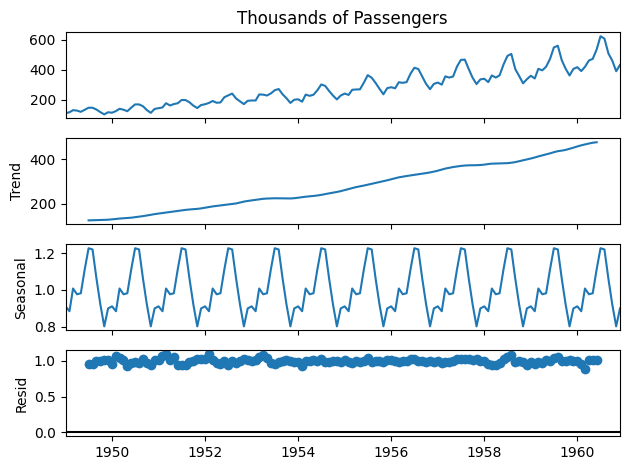

In [29]:
result=seasonal_decompose(df['Thousands of Passengers'],model='mul')
result.plot()
plt.show()

* Observation: Look at the Seasonal y-axis here. Instead of raw numbers, it shows factors (e.g., $0.8$ to $1.2$). This means "during this month, passengers are $1.2\times$ the trend."
* The Benefit: This model "stretches" the seasonal effect as the trend goes up. Even though the swings in the original data are getting bigger, the multiplicative seasonal pattern stays consistent as a percentage.
* The Result: Check the Resid plot. The points are much more tightly clustered around $1.0$. This indicates that the multiplicative model explains the data much better than the additive one for this specific dataset.

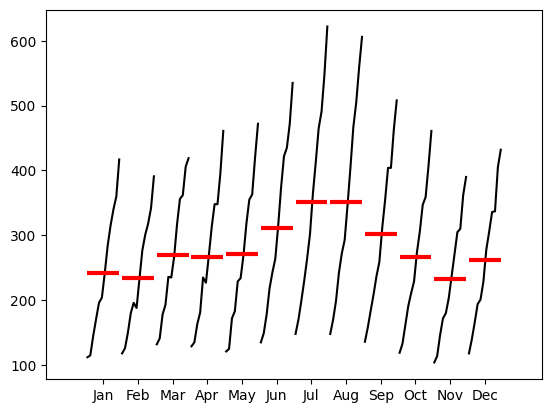

In [30]:
month_plot(df['Thousands of Passengers'])
plt.show()

- Peak Season: July and August have the highest red lines, confirming that summer is the busiest travel time.

- Low Season: November and February show the lowest averages, marking the typical "off-season" for airlines.

## ACF & PACF plots

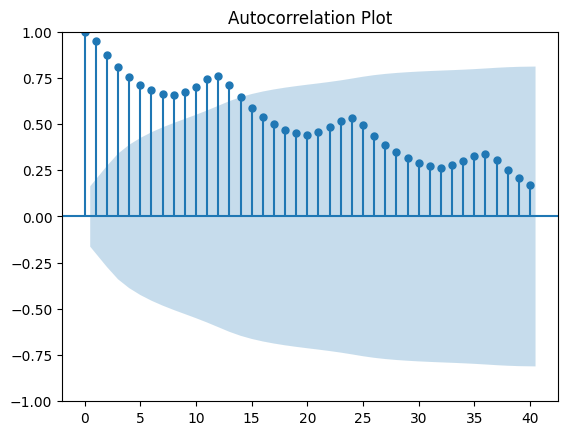

In [33]:
title = 'Autocorrelation Plot'
lags = 40
plot_acf(df["Thousands of Passengers"],title=title,lags=lags)
plt.show()

**- ACF Plot: The Signature of Non-Stationarity**
- Slow Decay: Notice how the blue bars decrease very slowly over time. This "slow tail-off" is a classic sign that the data is non-stationary and likely has a trend.

- Wavy Pattern: The "scalloped" or wavy shape with peaks around lag 12, 24, and 36 is the smoking gun for seasonality. It tells us that the value today is highly correlated with the value exactly one year (12 months) ago.

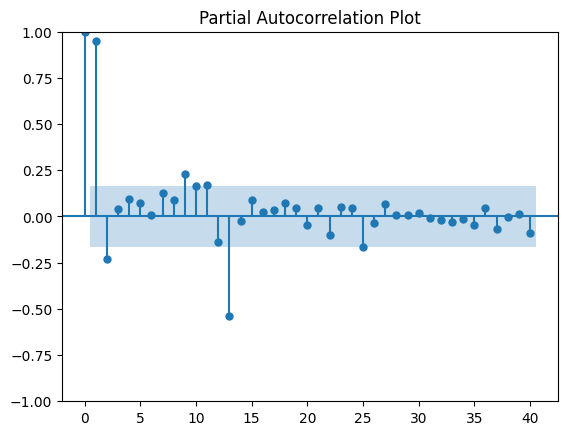

In [34]:
title = 'Partial Autocorrelation Plot'
lags = 40
plot_pacf(df["Thousands of Passengers"],title=title,lags=lags)
plt.show()

**PACF Plot: Identifying the AR component**
- Significant Lags: The PACF shows the correlation between a point and its lag after removing the influence of intermediate lags.

- Lag 1 Dominance: There is a very strong spike at Lag 1, which often suggests an Autoregressive (AR) component.

- Seasonal Spikes: Look at Lag 12 and 13. The significant negative spike at Lag 13 and the activity around Lag 12 further confirm that a seasonal differencing or a seasonal AR/MA term is needed.

# Test  For Stationarity

In [35]:
def adf_test(series):
    from statsmodels.tsa.stattools import adfuller

    result = adfuller(series)

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    for key, value in result[4].items():
        print(f"Critical Value ({key}): {value}")

    # interpretation
    if result[1] <= 0.05:
        print("✅ Stationary (reject H0)")
    else:
        print("❌ Non-stationary (fail to reject H0)")


In [36]:
adf_test(df['Thousands of Passengers'])

ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641
Critical Value (1%): -3.4816817173418295
Critical Value (5%): -2.8840418343195267
Critical Value (10%): -2.578770059171598
❌ Non-stationary (fail to reject H0)


### Some method To convert Non-stationary data to Stationary

## 1.Stationary After regular differencing

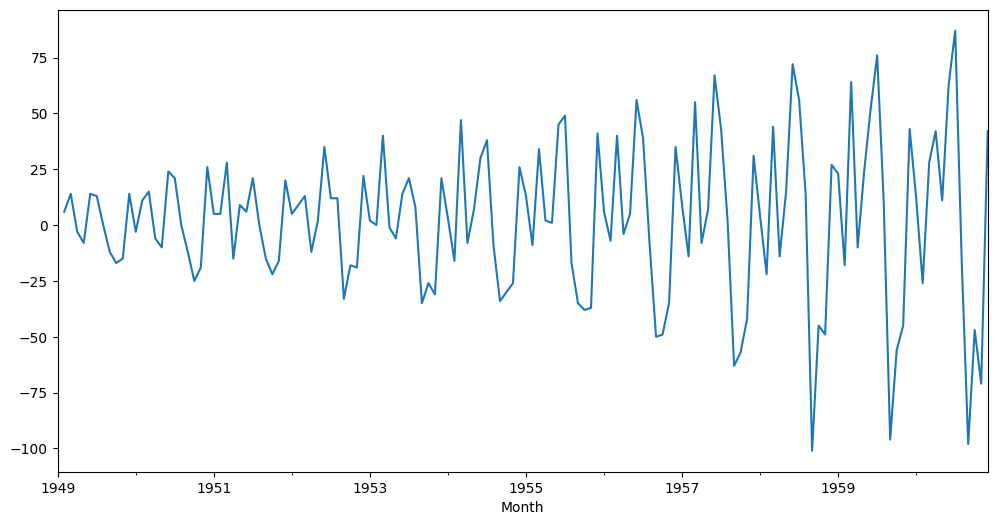

ADF Statistic: -2.8292668241700047
p-value: 0.05421329028382478
Critical Value (1%): -3.4816817173418295
Critical Value (5%): -2.8840418343195267
Critical Value (10%): -2.578770059171598
❌ Non-stationary (fail to reject H0)


In [44]:
df['difference_1']=diff(df['Thousands of Passengers'],k_diff=1)
df['difference_1'].plot(figsize=(12,6))
plt.show()
adf_test(df['difference_1'].dropna())

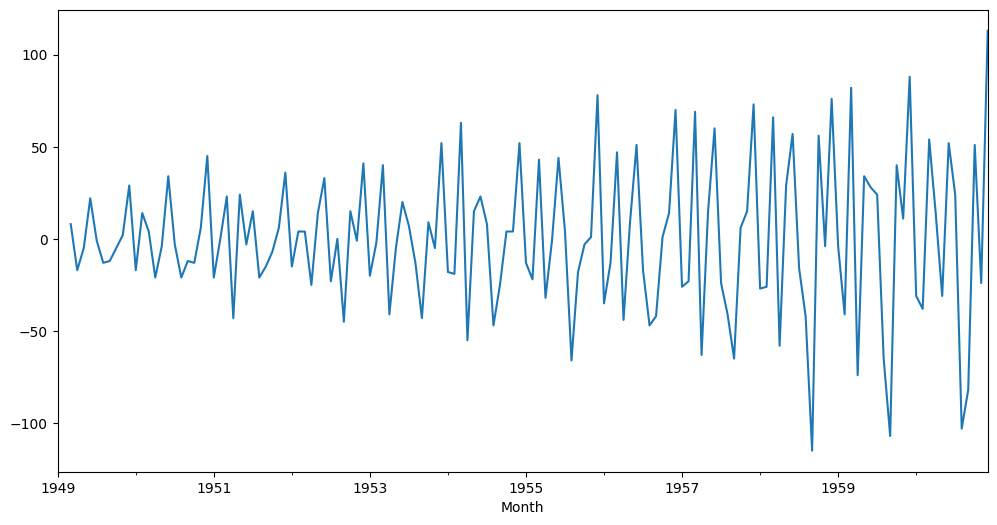

ADF Statistic: -16.384231542468513
p-value: 2.7328918500142026e-29
Critical Value (1%): -3.4816817173418295
Critical Value (5%): -2.8840418343195267
Critical Value (10%): -2.578770059171598
✅ Stationary (reject H0)


In [43]:
df['difference_2']=diff(df['Thousands of Passengers'],k_diff=2)
df['difference_2'].plot(figsize=(12,6))
plt.show()
adf_test(df['difference_2'].dropna())

## 2. Stationary Ater seasonal Differencing

<Axes: xlabel='Month'>

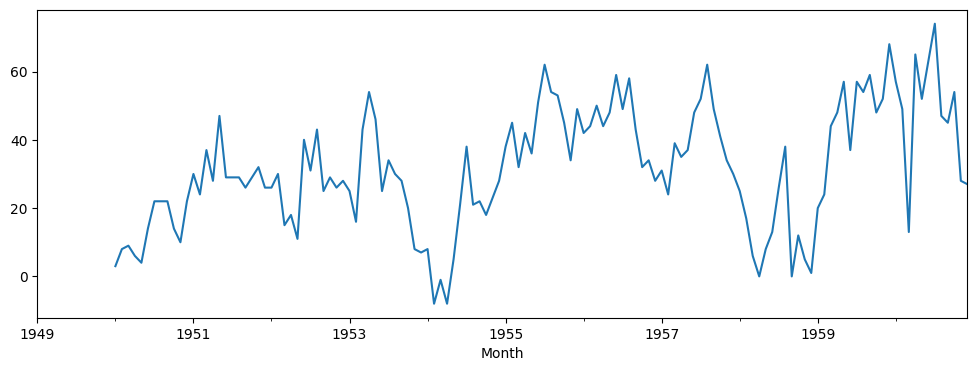

In [42]:
df["difference_seasonal"]= diff(df["Thousands of Passengers"], k_diff=0,k_seasonal_diff= 1,seasonal_periods= 12)
df["difference_seasonal"].plot(figsize=(12,4))

## 3. Box-cox Transformations

In [45]:
df['Weighted_Price_box'],lmbda=stats.boxcox(df['Thousands of Passengers'])
print(lmbda)

0.1480226858137178


In [46]:
adf_test(df['Weighted_Price_box'])

ADF Statistic: -1.32607080301317
p-value: 0.617162109223921
Critical Value (1%): -3.4816817173418295
Critical Value (5%): -2.8840418343195267
Critical Value (10%): -2.578770059171598
❌ Non-stationary (fail to reject H0)


In [48]:
adf_test(df['Weighted_Price_box'].diff().dropna())

ADF Statistic: -2.87170756048271
p-value: 0.048738329956575774
Critical Value (1%): -3.4825006939887997
Critical Value (5%): -2.884397984161377
Critical Value (10%): -2.578960197753906
✅ Stationary (reject H0)


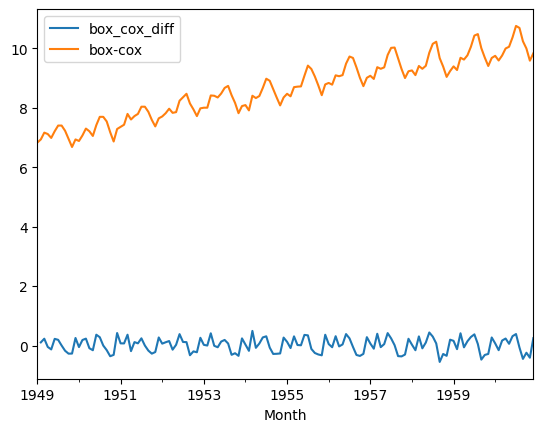

In [51]:
df['Weighted_Price_box'].diff().plot(label='box_cox_diff')
df['Weighted_Price_box'].plot(label='box-cox')
plt.legend()
plt.show()

# Train Test Split

In [52]:
len(df)

144

In [53]:
train= df.iloc[:len(df)-12]
test= df.iloc[len(df)-12:]

In [54]:
print(len(train))
print(len(test))

132
12


# ARIMA `(Seasonal=Flase)`

In [55]:
auto_arima_results=auto_arima(train['Thousands of Passengers'],
                              start_p=0,
                              start_q=0,
                              max_p=3,
                              max_q=3,
                              m=1,
                              d=None,
                              trace=True,
                              error_action='ignore',
                              suppress_warnings='True',
                              stepwise=True

                              )
auto_arima_results.summary()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1277.589, Time=0.13 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1268.313, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1264.738, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1276.259, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1258.440, Time=0.39 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.57 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.57 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1262.608, Time=0.40 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1263.896, Time=0.18 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1218.683, Time=0.63 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.43 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.34 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.27 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.14 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.35 sec
 A

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  132
Model:               SARIMAX(2, 1, 2)   Log Likelihood                -603.341
Date:                Sat, 02 May 2026   AIC                           1218.683
Time:                        07:31:02   BIC                           1235.934
Sample:                    01-01-1949   HQIC                          1225.692
                         - 12-01-1959                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.7157      0.212      3.379      0.001       0.301       1.131
ar.L1          1.6431      0.028     57.904      0.000       1.587       1.699
ar.L2         -0.9129      0.027    -33.338      0.000      -0.967      -0.859
ma.L1         -1.8478      0.036    -51.463      0.000      -1.918      -1.777
ma.L2          0.9466      0.038     24.988      0.000       0.872       1.021
sigma2       564.8459     67.205      8.405      0.000     433.126     696.566
===================================================================================
Ljung-Box (L1) (Q):                   0.85   Jarque-Bera (JB):                 1.87
Prob(Q):                              0.36   Prob(JB):                         0.39
Heteroskedasticity (H):               6.40   Skew:                             0.26
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.26
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

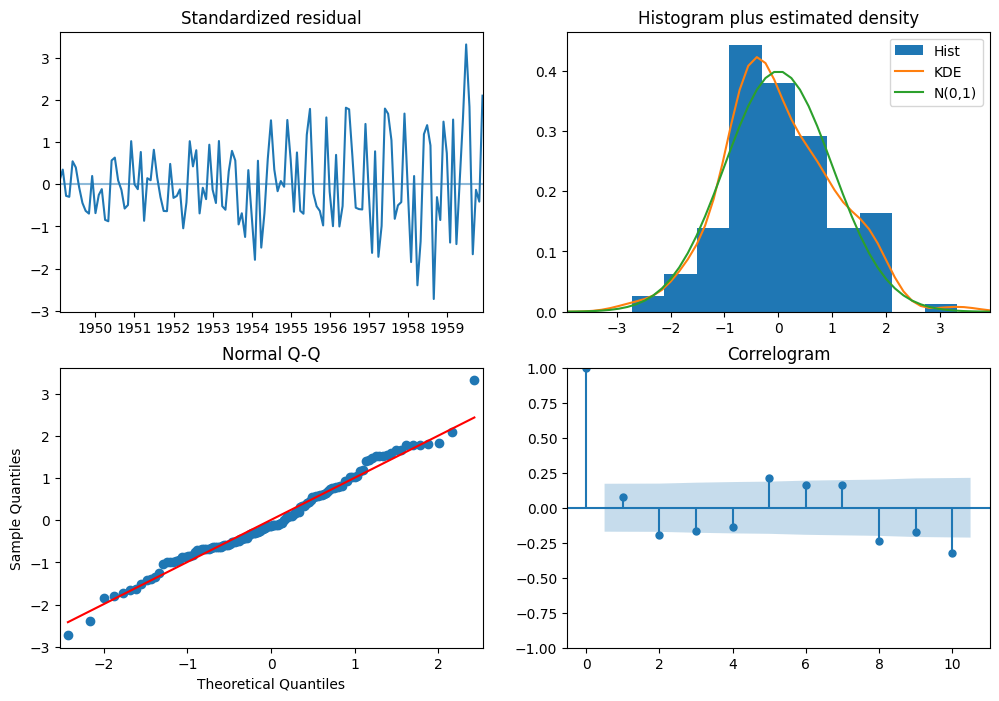

In [56]:
auto_arima_results.plot_diagnostics(figsize=(12,8))
plt.show()

Interpretation of plots in plot diagnostics Standardized residual: The residual errors seem to fluctuate around a mean of zero and have a uniform variance. Histogram: The density plot suggest normal distribution with mean slighlty shifted towards right. Theoretical Quantiles: Mostly the dots fall perfectly in line with the red line. Any significant deviations would imply the distribution is skewed. Correlogram: The Correlogram, (or ACF plot) shows the residual errors are not autocorrelated. The ACF plot would imply that there is some pattern in the residual errors which are not explained in the model. So we will need to look for more X’s (predictors) to the model.

## Arima model

In [58]:
arima_model=ARIMA(train['Thousands of Passengers'],
                  order=(2,1,2))
arima_model_fit=arima_model.fit()

In [61]:
start=len(train)
end=len(train)+len(test)-1
pred=arima_model_fit.predict(start=start,end=end,
                             dynamic=False,
                             typ='levels').rename("Arima Predictions")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


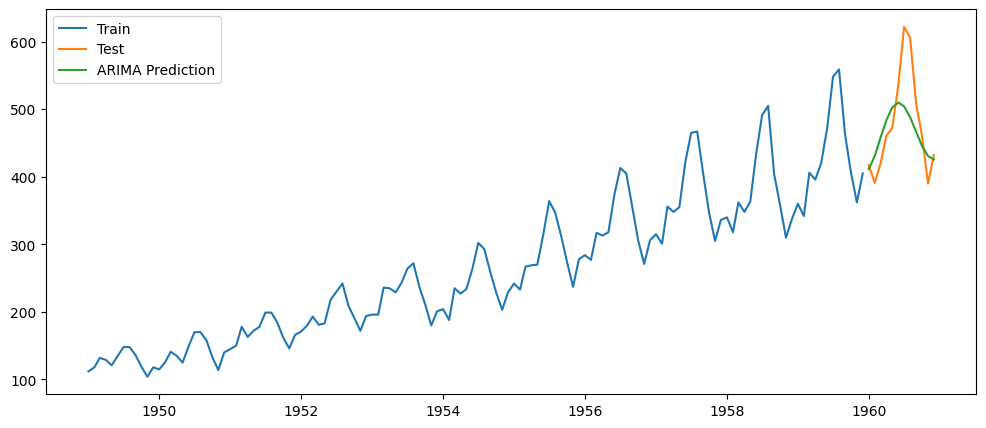

In [63]:
plt.figure(figsize=(12,5))
plt.plot(train["Thousands of Passengers"], label="Train")
plt.plot(test["Thousands of Passengers"], label="Test")
plt.plot(test.index, pred, label="ARIMA Prediction")
plt.legend()
plt.show()

<Axes: title={'center': 'Actual v/s Predictions for Test dataset'}, xlabel='Month'>

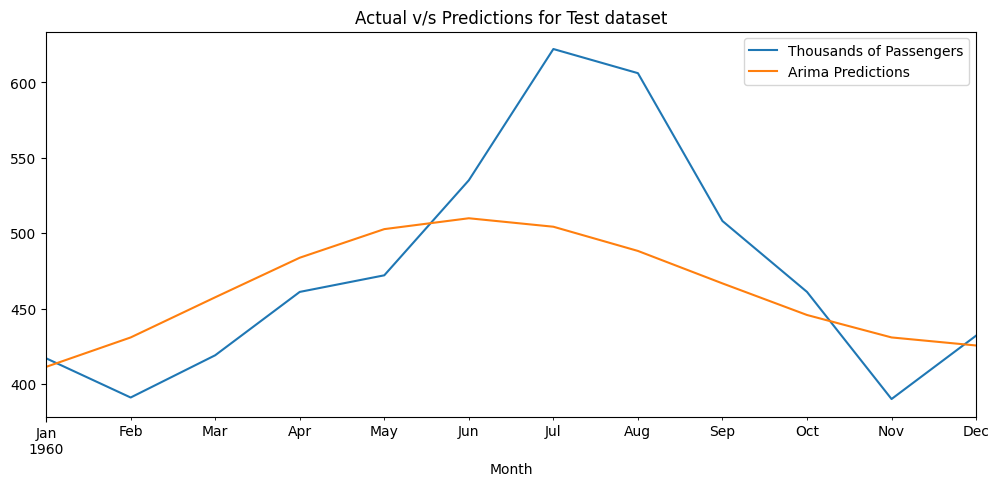

In [64]:
title= "Actual v/s Predictions for Test dataset"
test["Thousands of Passengers"].plot(figsize=(12,5), title= title, legend=True);
pred.plot(legend=True)

## Evaluate The model

In [65]:
mse= mean_squared_error(test["Thousands of Passengers"],pred)
rmse_arima= rmse(test["Thousands of Passengers"], pred)

print(f"Root Mean Square is {rmse_arima} \n")
print(f"Mean Square Error is {mse}")

Root Mean Square is 55.2228387419131 

Mean Square Error is 3049.561918715339


# SARIMA `(Seasonal=True)`

In [66]:
smodel=auto_arima(train['Thousands of Passengers'],
                  start_p=0,
                  start_q=0,
                  max_p=3,
                  max_q=3,
                  m=12,
                  start_P=0,
                  start_Q=0,
                  max_P=3,
                  max_Q=3,
                  d=None,
                  D=None,
                  trace=True,
                  error_action='ignore',
                  suppress_warnings=True,
                  stepwise=True)
smodel.summary()

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1022.234, Time=0.02 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=906.857, Time=0.21 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=963.555, Time=0.21 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1192.711, Time=0.02 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=907.180, Time=0.06 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=908.543, Time=0.67 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.60 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=907.120, Time=0.25 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=1.87 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=1021.611, Time=0.15 sec
 ARIMA(2,0,0)(1,1,0)[12] intercept   : AIC=906.396, Time=0.32 sec
 ARIMA(2,0,0)(0,1,0)[12] intercept   : AIC=906.075, Time=0.08 sec
 ARIMA(2,0,0)(0,1,1)[12] intercept   : AIC=906.713, Time=0.22 sec
 ARIMA(2,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.65 sec
 ARIMA(3,0,0)(0,1,0)[12] intercept   : AIC

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  132
Model:             SARIMAX(3, 0, 0)x(0, 1, 0, 12)   Log Likelihood                -447.843
Date:                            Sat, 02 May 2026   AIC                            905.686
Time:                                    07:50:19   BIC                            919.623
Sample:                                01-01-1949   HQIC                           911.346
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      5.5341      2.007      2.757      0.006       1.600       9.468
ar.L1          0.7049      0.095      7.393      0.000       0.518       0.892
ar.L2          0.2574      0.131      1.968      0.049       0.001       0.514
ar.L3         -0.1434      0.107     -1.338      0.181      -0.354       0.067
sigma2       101.0969     12.818      7.887      0.000      75.974     126.220
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.83
Prob(Q):                              0.96   Prob(JB):                         0.24
Heteroskedasticity (H):               1.41   Skew:                            -0.14
Prob(H) (two-sided):                  0.29   Kurtosis:                         3.70
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Sarima Model

In [67]:
sarima_model=SARIMAX(train['Thousands of Passengers'],
                     order=(3,0,3),
                     seasonal_order=(0,1,0,12))
sarima_model_fit=sarima_model.fit()

In [68]:
start=len(train)
end=len(train)+len(test)-1
preds=sarima_model_fit.predict(start=start,end=end,
                             dynamic=False,
                             typ='levels').rename("Sarima Predictions")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


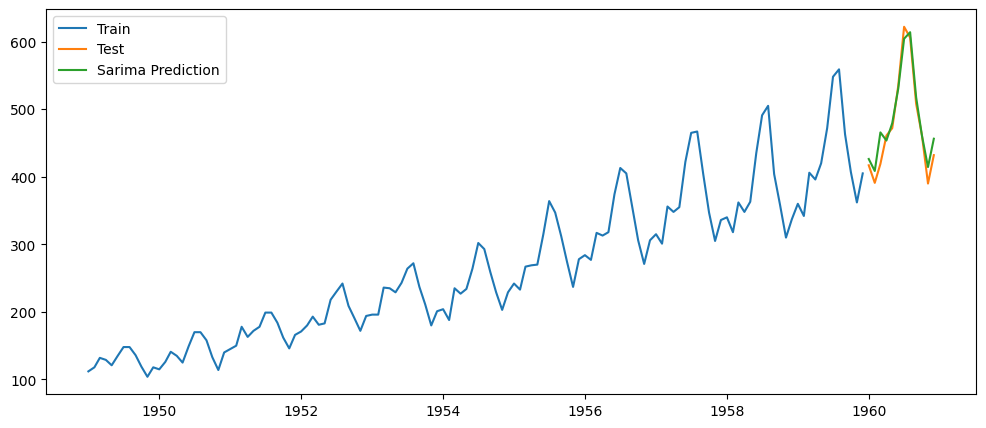

In [69]:
plt.figure(figsize=(12,5))
plt.plot(train["Thousands of Passengers"], label="Train")
plt.plot(test["Thousands of Passengers"], label="Test")
plt.plot(test.index, preds, label="Sarima Prediction")
plt.legend()
plt.show()

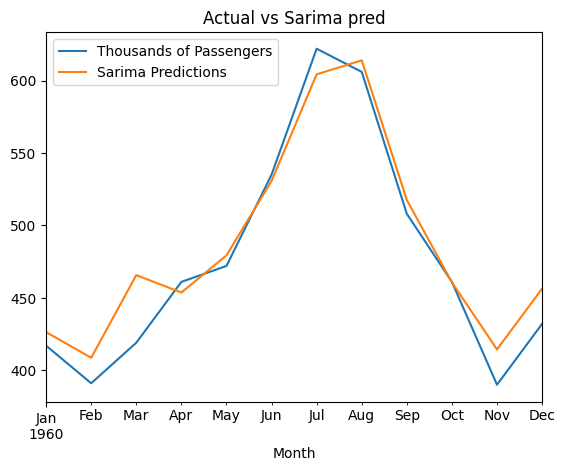

In [71]:
test['Thousands of Passengers'].plot(title='Actual vs Sarima pred',legend=True)
preds.plot(legend=True)
plt.show()

## Evaluate the model

In [73]:
#Evaluate the model
mse= mean_squared_error(test["Thousands of Passengers"],preds)
rmse_sarima= rmse(test["Thousands of Passengers"], preds)

print(f"Root Mean Square is {rmse_sarima} \n")
print(f"Mean Square Error is {mse}")

Root Mean Square is 19.050653428944106 

Mean Square Error is 362.9273960697398


# Future Forecast

Re train SARIMA model on entrie data and make future forecast

In [77]:
model_final=SARIMAX(df['Thousands of Passengers'],
                   order=(3,0,0),
                   seasonal_order=(0,1,0,12))
results=model_final.fit()

start=len(df)
end=len(df)+len(test)-1

pred=results.predict(start=start,
                     end=end,
                     dynamic=False,
                     type='levels').rename('Future Forecasts')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['type']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


## Plot the forecasts

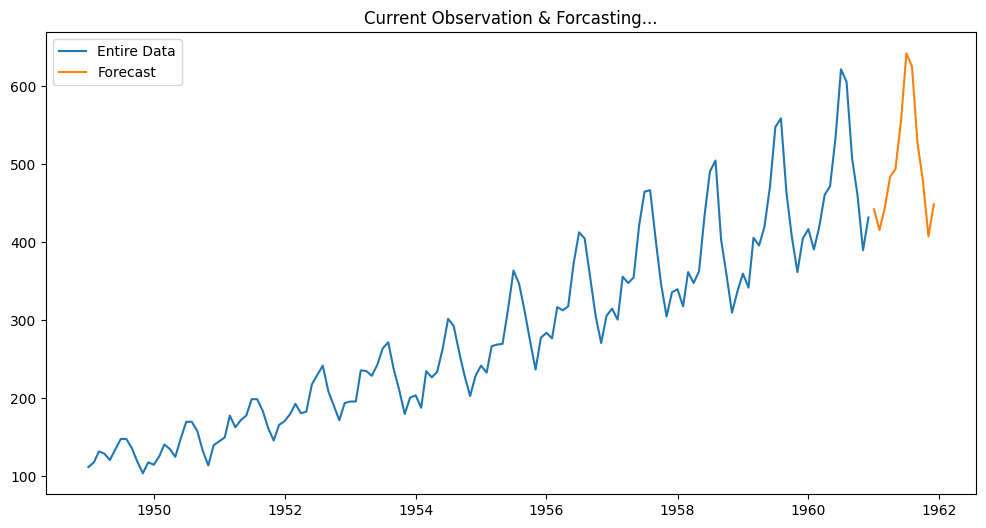

In [78]:
plt.figure(figsize=(12,6))
plt.plot(df['Thousands of Passengers'],label='Entire Data')
plt.plot(pred,label='Forecast')
plt.title("Current Observation & Forcasting...")
plt.legend()
plt.show()



---

---
**Z.I. Turjo**


---

---






